# 🔍 Análise Exploratória de Dados (EDA) e Modelagem

Este notebook realiza a análise dos dados de consumo de energia e emissões de CO2, focando em:
1. Carregamento e inspeção do dataset sintético.
2. Limpeza e preparação dos dados.
3. Visualização de tendências setoriais e regionais.
4. Classificação de impacto ambiental.
5. Treinamento de um modelo de Árvore de Decisão.

---

## 1. Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


## 2. Carregamento do Dataset

Os dados são carregados diretamente do repositório GitHub do projeto.

In [2]:
import os

colab_path = "/content/carbon-footprint-analysis/data/processed/synthetic_energy_emissions_dataset.csv"
local_path = os.path.join('..', 'data', 'processed', 'synthetic_energy_emissions_dataset.csv')
github_url = (
    'https://raw.githubusercontent.com/carbon-footprint-analysis/'
    'carbon-footprint-analysis/main/data/processed/synthetic_energy_emissions_dataset.csv'
)

if os.path.exists(colab_path):
    data_path = colab_path
elif os.path.exists(local_path):
    data_path = local_path
else:
    data_path = github_url

df = pd.read_csv(data_path).drop(columns=['Unnamed: 0'], errors='ignore')

print(f'✅ Dataset carregado com sucesso!')
print(f'   Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas\n')
display(df.head())

✅ Dataset carregado com sucesso!
   Dimensões: 100000 linhas × 12 colunas



,id_empresa,data,estado,setor,porte,tipo_combustivel,consumo_kwh,fonte_energia,emissao_co2,modal_transporte,km_transporte,emissao_transporte_co2
0,C228154,2025-09-02,DF,industrial,small,electric,19691.786482,hidrelétrica,85.154433,moto,820.53,92.7198
1,C544863,2025-07-06,MG,outros,large,electric,5884.049610,eólica,61.693557,metro_trem,186.66,1.1200
2,C898300,2025-04-13,SP,residencial,small,electric,303.184946,hidrelétrica,1.083152,carro,111.98,21.5010
3,C980827,2025-06-13,MS,residencial,small,electric,98.789450,hidrelétrica,0.377149,carro,291.33,55.9352
4,C319070,2025-08-22,BA,residencial,small,electric,177.441915,eólica,2.128812,metro_trem,518.29,3.1097


## 3. Inspeção e Limpeza dos Dados

In [3]:
# Tipos de dados e valores nulos
print('--- Informações Gerais ---')
df.info()

print('\n--- Estatísticas Descritivas ---')
display(df.describe())

print('\n--- Valores Nulos por Coluna ---')
print(df.isnull().sum())

--- Informações Gerais ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id_empresa              100000 non-null  object 
 1   data                    100000 non-null  object 
 2   estado                  100000 non-null  object 
 3   setor                   100000 non-null  object 
 4   porte                   100000 non-null  object 
 5   tipo_combustivel        100000 non-null  object 
 6   consumo_kwh             100000 non-null  float64
 7   fonte_energia           100000 non-null  object 
 8   emissao_co2             100000 non-null  float64
 9   modal_transporte        100000 non-null  object 
 10  km_transporte           100000 non-null  float64
 11  emissao_transporte_co2  100000 non-null  float64
dtypes: float64(4), object(8)
memory usage: 9.2+ MB

--- Estatísticas Descritivas ---


,consumo_kwh,emissao_co2,km_transporte,emissao_transporte_co2
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,17980.133414,3419.964662,552.525336,68.463868
std,27676.419759,12258.605352,394.699558,70.303355
min,40.215377,0.179844,27.320000,0.000000
25%,266.933544,4.587296,297.680000,22.850950
50%,2420.089867,85.960996,460.440000,52.381750
75%,29294.954821,355.304772,693.012500,93.866600
max,431872.894375,242839.933328,10837.220000,2080.746400



--- Valores Nulos por Coluna ---
id_empresa                0
data                      0
estado                    0
setor                     0
porte                     0
tipo_combustivel          0
consumo_kwh               0
fonte_energia             0
emissao_co2               0
modal_transporte          0
km_transporte             0
emissao_transporte_co2    0
dtype: int64


### 3.1 Conversão de Tipos

In [4]:
# Converter coluna de data
df['data'] = pd.to_datetime(df['data'])

# Garantir que colunas numéricas estejam no tipo correto
for col in ['consumo_kwh', 'emissao_co2']:
    if df[col].dtype == object:
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('✅ Conversão de tipos concluída!')
print(df.dtypes)

✅ Conversão de tipos concluída!
id_empresa                        object
data                      datetime64[ns]
estado                            object
setor                             object
porte                             object
tipo_combustivel                  object
consumo_kwh                      float64
fonte_energia                     object
emissao_co2                      float64
modal_transporte                  object
km_transporte                    float64
emissao_transporte_co2           float64
dtype: object


## 4. Análise Exploratória — Relatório Executivo

In [5]:
# Agregações
setor_emissao   = df.groupby('setor')['emissao_co2'].sum().sort_values(ascending=False).reset_index()
top_estados     = df.groupby('estado')['emissao_co2'].sum().sort_values(ascending=False).head(10).reset_index()
resumo_fontes   = df.groupby('fonte_energia')[['emissao_co2', 'consumo_kwh']].sum()
intensidade     = (resumo_fontes['emissao_co2'] / resumo_fontes['consumo_kwh']).sort_values(ascending=False)

# Relatório no console
print('=' * 50)
print('📊 RELATÓRIO EXECUTIVO DE EMISSÕES DE CO2')
print('=' * 50)

print('\n[1] EMISSÕES TOTAIS POR SETOR (kg CO2):')
for _, row in setor_emissao.iterrows():
    print(f"  - {row['setor'].capitalize()}: {row['emissao_co2']:,.2f} kg")

print('\n[2] TOP 5 ESTADOS COM MAIORES EMISSÕES:')
for _, row in top_estados.head(5).iterrows():
    print(f"  - {row['estado']}: {row['emissao_co2']:,.2f} kg")

print('\n[3] INTENSIDADE DE CARBONO POR FONTE (kg CO2/kWh):')
for fonte, valor in intensidade.items():
    print(f"  - {fonte.capitalize()}: {valor:.4f} kg CO2/kWh")
print('=' * 50)

📊 RELATÓRIO EXECUTIVO DE EMISSÕES DE CO2

[1] EMISSÕES TOTAIS POR SETOR (kg CO2):
  - Industrial: 325,072,937.97 kg
  - Outros: 9,903,503.47 kg
  - Comercial: 5,186,482.00 kg
  - Residencial: 1,013,587.96 kg
  - Rural: 819,954.77 kg

[2] TOP 5 ESTADOS COM MAIORES EMISSÕES:
  - SP: 97,436,415.88 kg
  - MG: 60,052,743.25 kg
  - PA: 24,032,726.48 kg
  - PR: 21,857,500.80 kg
  - RS: 19,021,599.56 kg

[3] INTENSIDADE DE CARBONO POR FONTE (kg CO2/kWh):
  - Térmica: 0.8194 kg CO2/kWh
  - Solar: 0.0450 kg CO2/kWh
  - Nuclear: 0.0120 kg CO2/kWh
  - Eólica: 0.0110 kg CO2/kWh
  - Hidrelétrica: 0.0040 kg CO2/kWh


### 4.1 Visualizações Gráficas

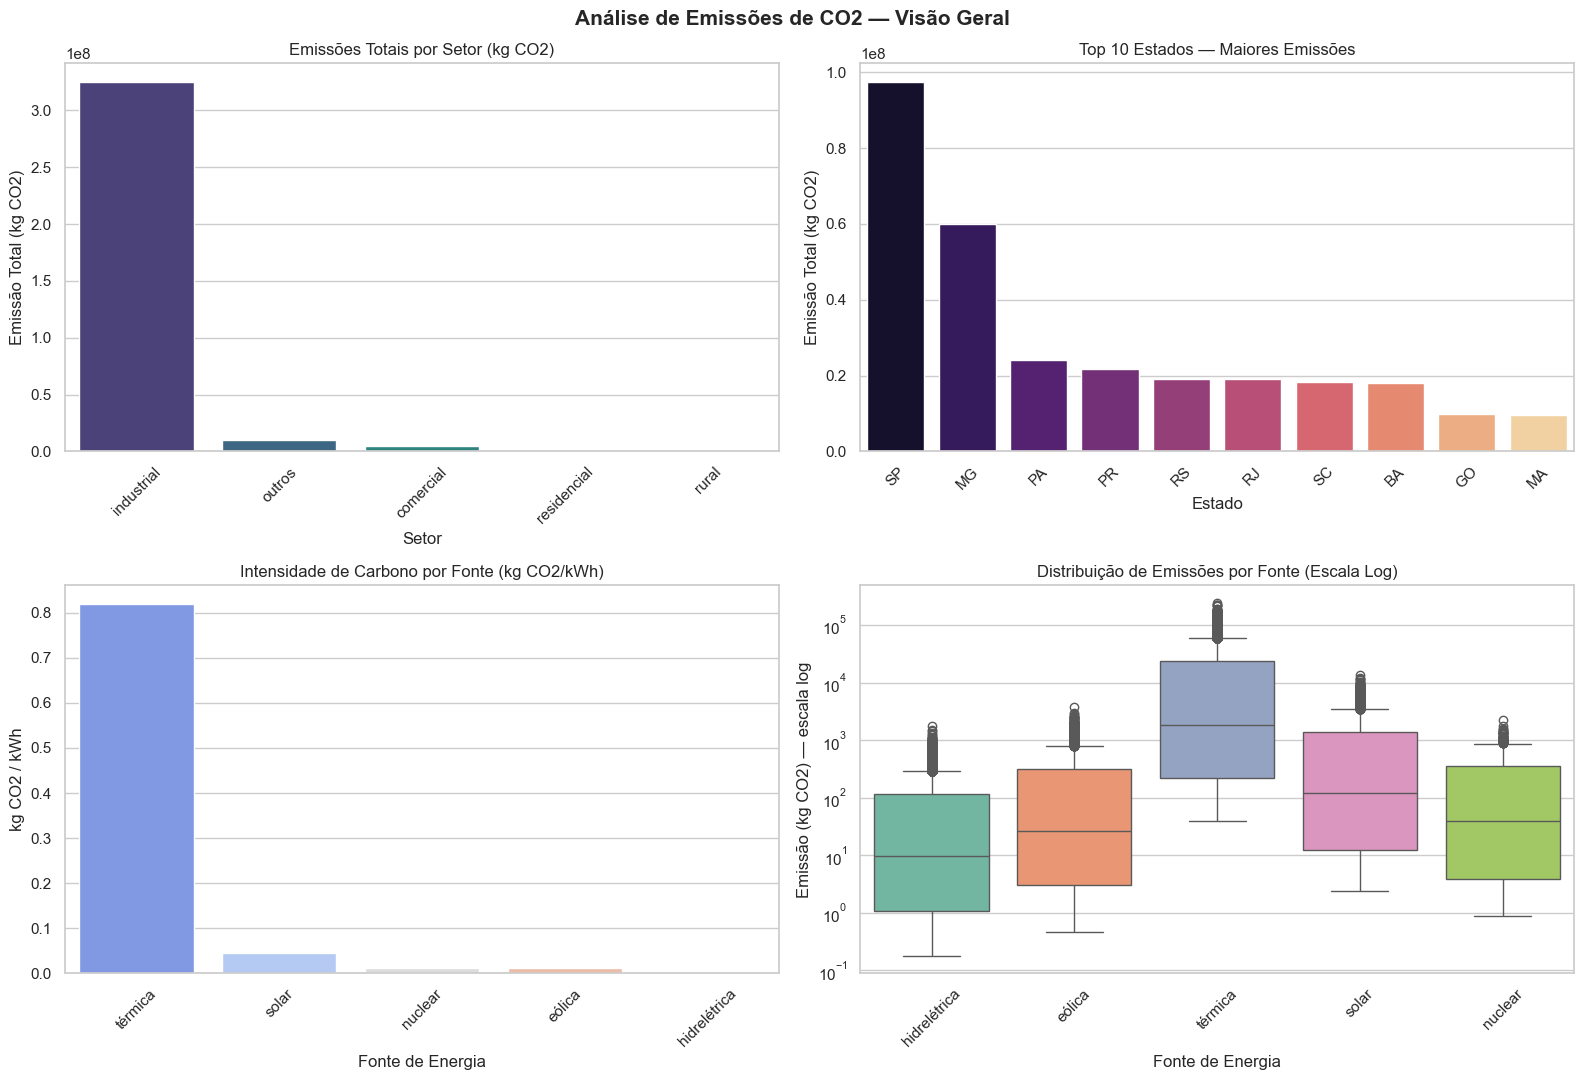

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Análise de Emissões de CO2 — Visão Geral', fontsize=15, fontweight='bold')

# Gráfico 1: Emissões por setor
sns.barplot(ax=axes[0, 0], data=setor_emissao, x='setor', y='emissao_co2',
            hue='setor', palette='viridis', legend=False)
axes[0, 0].set_title('Emissões Totais por Setor (kg CO2)')
axes[0, 0].set_xlabel('Setor')
axes[0, 0].set_ylabel('Emissão Total (kg CO2)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Gráfico 2: Top 10 estados
sns.barplot(ax=axes[0, 1], data=top_estados, x='estado', y='emissao_co2',
            hue='estado', palette='magma', legend=False)
axes[0, 1].set_title('Top 10 Estados — Maiores Emissões')
axes[0, 1].set_xlabel('Estado')
axes[0, 1].set_ylabel('Emissão Total (kg CO2)')
axes[0, 1].tick_params(axis='x', rotation=45)

# Gráfico 3: Intensidade de carbono por fonte
sns.barplot(ax=axes[1, 0], x=intensidade.index, y=intensidade.values,
            palette='coolwarm', legend=False)
axes[1, 0].set_title('Intensidade de Carbono por Fonte (kg CO2/kWh)')
axes[1, 0].set_xlabel('Fonte de Energia')
axes[1, 0].set_ylabel('kg CO2 / kWh')
axes[1, 0].tick_params(axis='x', rotation=45)

# Gráfico 4: Boxplot distribuição de emissões por fonte
sns.boxplot(ax=axes[1, 1], data=df, x='fonte_energia', y='emissao_co2',
            hue='fonte_energia', palette='Set2', legend=False)
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Distribuição de Emissões por Fonte (Escala Log)')
axes[1, 1].set_xlabel('Fonte de Energia')
axes[1, 1].set_ylabel('Emissão (kg CO2) — escala log')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4.2 Análise de Mobilidade — Modal de Transporte

Além do consumo energético, o dataset inclui a dimensão de **mobilidade corporativa**: modal de transporte utilizado, distância percorrida e emissão de CO₂ associada.

Essa dimensão cobre emissões de **Escopo 1** (combustão direta em veículos próprios) e **Escopo 3** (deslocamento de funcionários), complementando as emissões de Escopo 2 (energia elétrica) já analisadas.

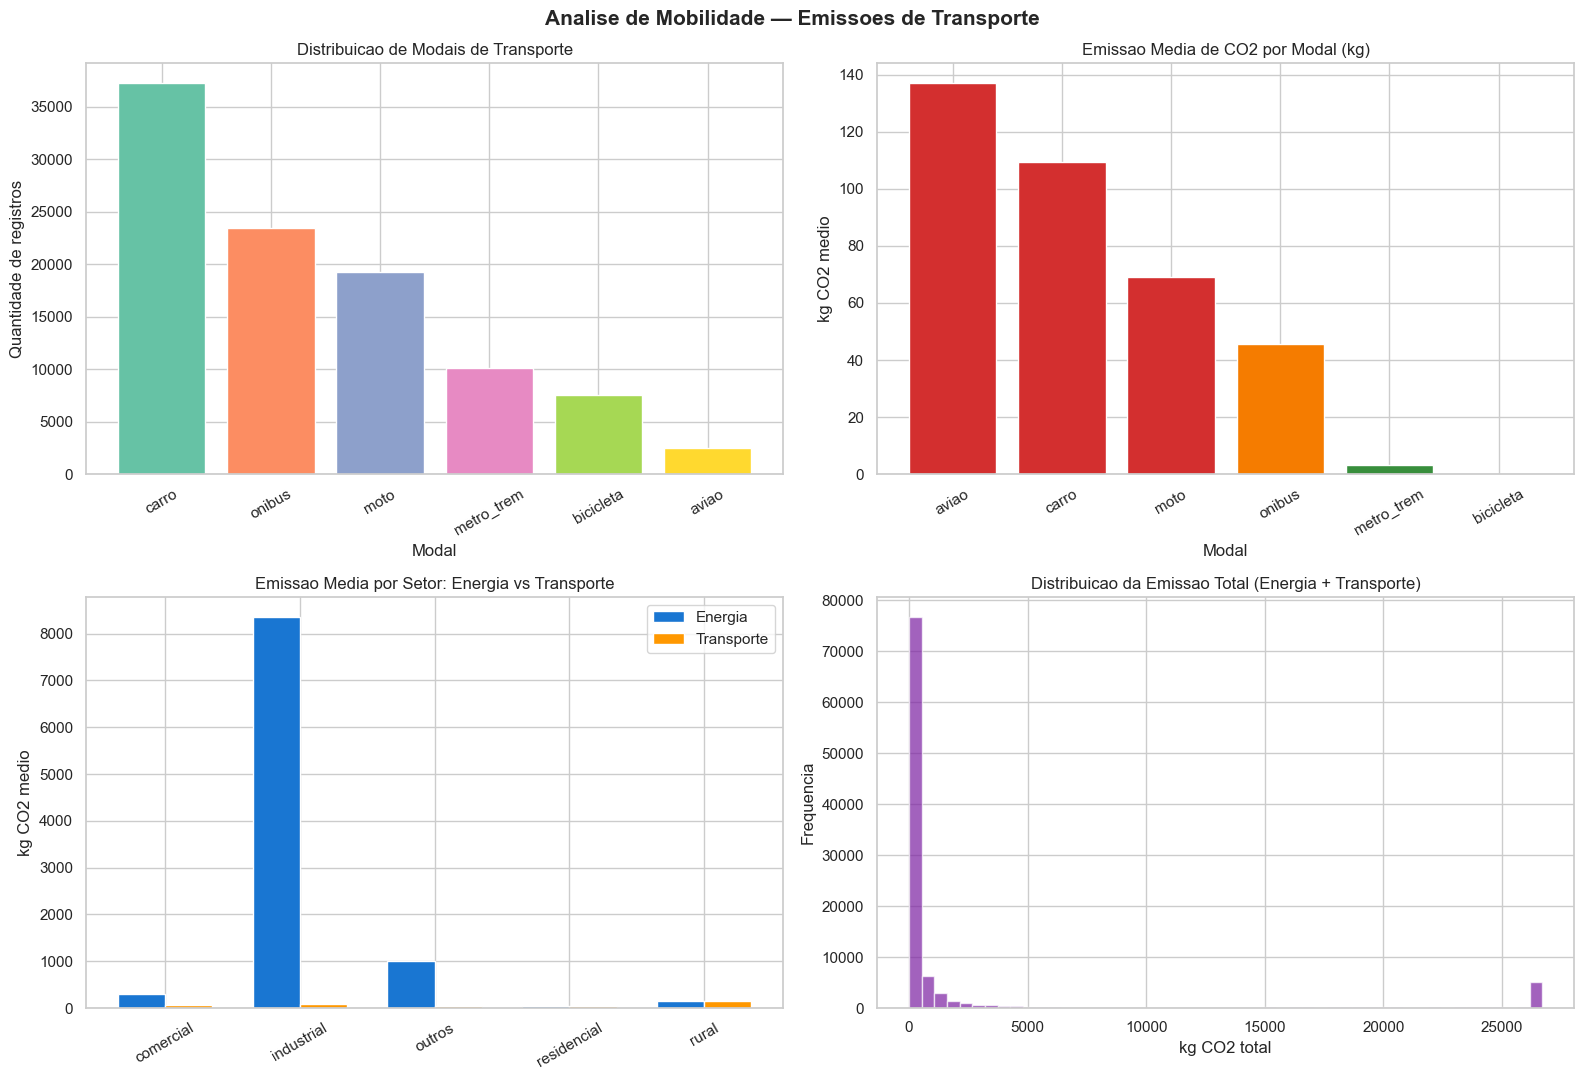

=== RESUMO EXECUTIVO — TRANSPORTE ===
Emissao media de energia:        3419.96 kg CO2
Emissao media de transporte:       68.46 kg CO2
Emissao total media:             3488.43 kg CO2
Transporte representa:              2.0% da emissao total

Modal mais poluente (media): aviao
Modal mais usado: carro


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Verificar se as colunas de transporte existem
transport_cols = ['modal_transporte', 'km_transporte', 'emissao_transporte_co2']
has_transport = all(c in df.columns for c in transport_cols)

if not has_transport:
    print('Dataset sem colunas de transporte. Execute o notebook 01 atualizado para regenerar.')
else:
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    fig.suptitle('Analise de Mobilidade — Emissoes de Transporte', fontsize=15, fontweight='bold')

    # 1. Distribuicao de modais
    modal_counts = df['modal_transporte'].value_counts()
    axes[0, 0].bar(modal_counts.index, modal_counts.values,
                   color=sns.color_palette('Set2', len(modal_counts)))
    axes[0, 0].set_title('Distribuicao de Modais de Transporte')
    axes[0, 0].set_xlabel('Modal')
    axes[0, 0].set_ylabel('Quantidade de registros')
    axes[0, 0].tick_params(axis='x', rotation=30)

    # 2. Emissao media por modal
    emissao_modal = df.groupby('modal_transporte')['emissao_transporte_co2'].mean().sort_values(ascending=False)
    colors = ['#d32f2f' if v > 50 else '#f57c00' if v > 10 else '#388e3c'
              for v in emissao_modal.values]
    axes[0, 1].bar(emissao_modal.index, emissao_modal.values, color=colors)
    axes[0, 1].set_title('Emissao Media de CO2 por Modal (kg)')
    axes[0, 1].set_xlabel('Modal')
    axes[0, 1].set_ylabel('kg CO2 medio')
    axes[0, 1].tick_params(axis='x', rotation=30)

    # 3. Comparacao energia vs transporte por setor
    comp = df.groupby('setor')[['emissao_co2', 'emissao_transporte_co2']].mean()
    x = np.arange(len(comp))
    w = 0.35
    axes[1, 0].bar(x - w/2, comp['emissao_co2'], w, label='Energia', color='#1976D2')
    axes[1, 0].bar(x + w/2, comp['emissao_transporte_co2'], w, label='Transporte', color='#FF9800')
    axes[1, 0].set_title('Emissao Media por Setor: Energia vs Transporte')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(comp.index, rotation=30)
    axes[1, 0].set_ylabel('kg CO2 medio')
    axes[1, 0].legend()

    # 4. Distribuicao de emissao total (energia + transporte)
    df['emissao_total_co2'] = df['emissao_co2'] + df['emissao_transporte_co2']
    df['emissao_total_co2'].clip(upper=df['emissao_total_co2'].quantile(0.95)).hist(
        bins=50, ax=axes[1, 1], color='#7B1FA2', alpha=0.7, edgecolor='white'
    )
    axes[1, 1].set_title('Distribuicao da Emissao Total (Energia + Transporte)')
    axes[1, 1].set_xlabel('kg CO2 total')
    axes[1, 1].set_ylabel('Frequencia')

    plt.tight_layout()
    plt.show()

    # Resumo executivo
    print('=== RESUMO EXECUTIVO — TRANSPORTE ===')
    print(f"Emissao media de energia:     {df['emissao_co2'].mean():>10.2f} kg CO2")
    print(f"Emissao media de transporte:  {df['emissao_transporte_co2'].mean():>10.2f} kg CO2")
    print(f"Emissao total media:          {df['emissao_total_co2'].mean():>10.2f} kg CO2")
    pct = df['emissao_transporte_co2'].mean() / df['emissao_total_co2'].mean() * 100
    print(f"Transporte representa:        {pct:>9.1f}% da emissao total")
    print()
    print('Modal mais poluente (media):',
          df.groupby('modal_transporte')['emissao_transporte_co2'].mean().idxmax())
    print('Modal mais usado:',
          df['modal_transporte'].value_counts().idxmax())

### Conclusões — Mobilidade

A análise dos modais de transporte revela insights complementares à análise energética:

- **O avião e o carro são os modais mais poluentes por km**, com fatores de emissão até 40x maiores que o metrô/trem.
- **O setor rural apresenta maior emissão de transporte**, reflexo de longas distâncias percorridas e dependência do carro/moto.
- **A emissão de transporte é secundária em relação à energia** na maioria dos setores, mas representa uma parcela relevante nos perfis residencial e comercial — onde o consumo energético é menor.
- **A substituição do carro pelo transporte coletivo ou modal ativo (bicicleta)** é a principal alavanca de redução nas emissões de mobilidade.

Essas variáveis são exploradas no dashboard (`app.py`) na aba **Pegada Total**, que soma emissões de energia e transporte para uma visão completa da pegada de carbono.

## 5. Classificação de Impacto Ambiental

Criamos uma nova coluna categórica com base nos percentis 33% e 66% das emissões.

✅ NOVA VARIÁVEL: IMPACTO AMBIENTAL
  - Baixo Impacto: 33000 registros (33.0%)
  - Médio Impacto: 33000 registros (33.0%)
  - Alto Impacto: 34000 registros (34.0%)


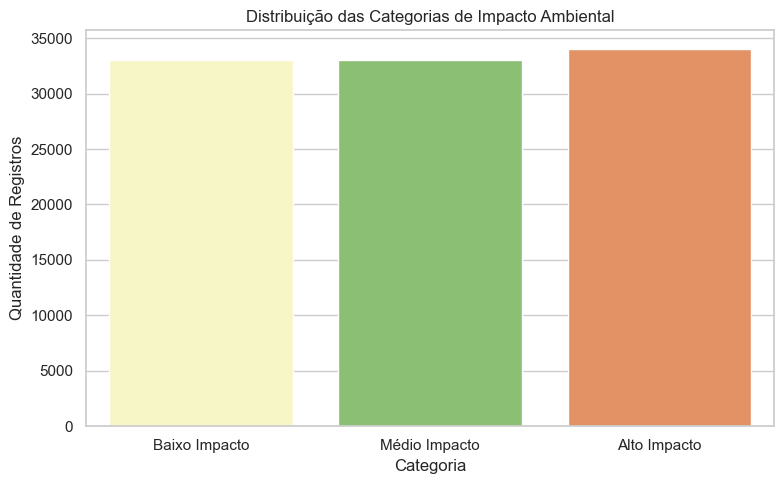

In [8]:
limites = df['emissao_co2'].quantile([0.33, 0.66]).values

def categorizar_impacto(valor):
    if valor <= limites[0]:
        return 'Baixo Impacto'
    elif valor <= limites[1]:
        return 'Médio Impacto'
    return 'Alto Impacto'

df['impacto_ambiental'] = df['emissao_co2'].apply(categorizar_impacto)

print('=' * 50)
print('✅ NOVA VARIÁVEL: IMPACTO AMBIENTAL')
print('=' * 50)
contagem   = df['impacto_ambiental'].value_counts()
porcentagem = df['impacto_ambiental'].value_counts(normalize=True) * 100
for cat in ['Baixo Impacto', 'Médio Impacto', 'Alto Impacto']:
    print(f"  - {cat}: {contagem[cat]} registros ({porcentagem[cat]:.1f}%)")

# Visualização
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='impacto_ambiental',
              order=['Baixo Impacto', 'Médio Impacto', 'Alto Impacto'],
              hue='impacto_ambiental', palette='RdYlGn_r', legend=False)
plt.title('Distribuição das Categorias de Impacto Ambiental')
plt.xlabel('Categoria')
plt.ylabel('Quantidade de Registros')
plt.tight_layout()
plt.show()

### 5.1 Salvar Dataset Processado

In [9]:
import os

caminho_processado = '../data/processed/dados_energia_limpos.csv'
os.makedirs(os.path.dirname(caminho_processado), exist_ok=True)
df.to_csv(caminho_processado, index=False)
print(f'💾 Dataset processado salvo em: {caminho_processado}')
print(f'   Dimensões finais: {df.shape[0]} linhas × {df.shape[1]} colunas')

💾 Dataset processado salvo em: ../data/processed/dados_energia_limpos.csv
   Dimensões finais: 100000 linhas × 14 colunas


## 6. Modelagem — Árvore de Decisão

Treinamos um modelo de classificação para prever o impacto ambiental com base no consumo (kWh) e no setor da empresa.

In [10]:
# Codificar variável categórica 'setor'
df_modelo = df.copy()
df_modelo['setor_encoded'] = df_modelo['setor'].astype('category').cat.codes

X = df_modelo[['consumo_kwh', 'setor_encoded']]
y = df_modelo['impacto_ambiental']

# Divisão treino/teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Treinar o modelo
modelo = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo.fit(X_treino, y_treino)

# Relatório de desempenho
previsoes = modelo.predict(X_teste)
print('=' * 50)
print('🤖 RELATÓRIO DO MODELO PREDITIVO')
print('=' * 50)
print(classification_report(y_teste, previsoes))

🤖 RELATÓRIO DO MODELO PREDITIVO
               precision    recall  f1-score   support

 Alto Impacto       0.97      0.37      0.53      6675
Baixo Impacto       0.66      1.00      0.79      6619
Médio Impacto       0.60      0.67      0.63      6706

     accuracy                           0.68     20000
    macro avg       0.74      0.68      0.65     20000
 weighted avg       0.74      0.68      0.65     20000



### 6.1 Visualização da Árvore de Decisão

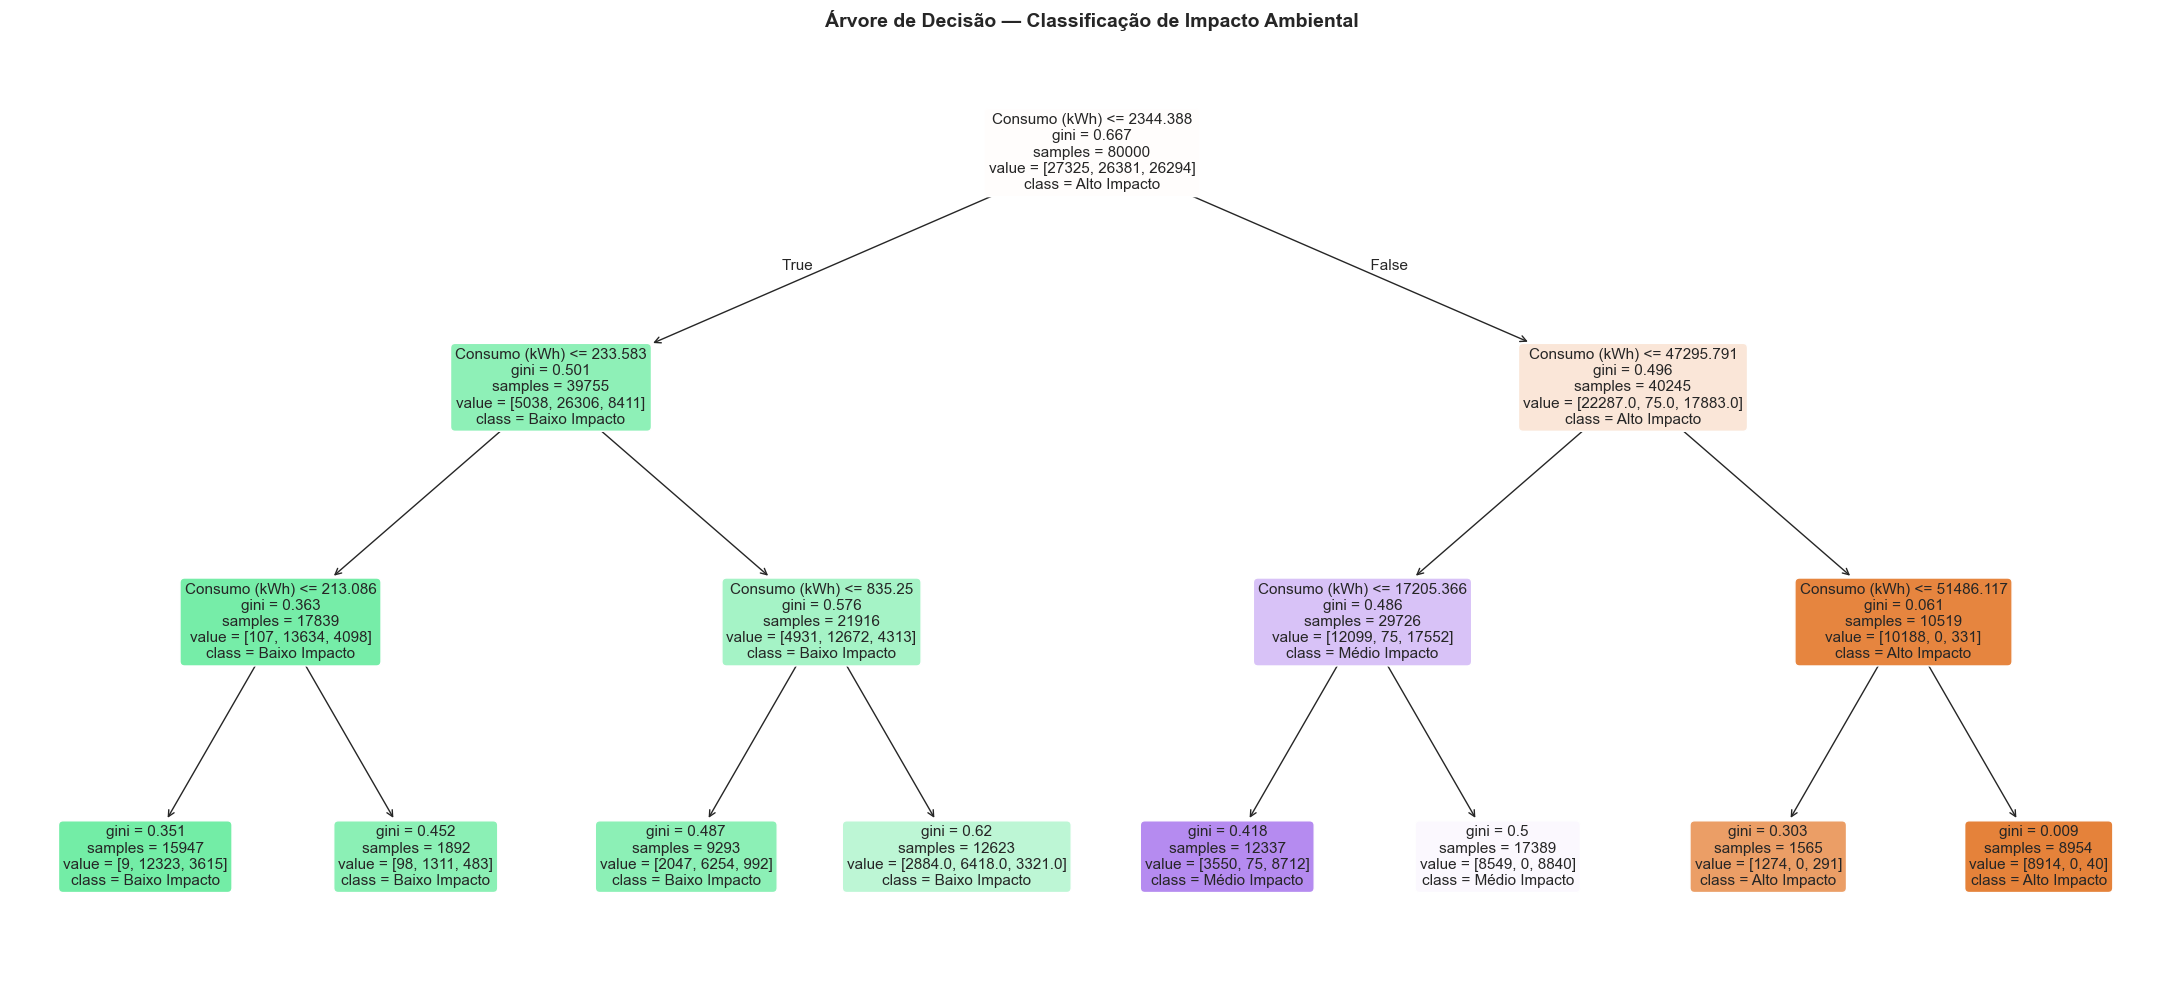

In [11]:
plt.figure(figsize=(22, 10))
plot_tree(
    modelo,
    feature_names=['Consumo (kWh)', 'Setor (encoded)'],
    class_names=modelo.classes_,
    filled=True,
    rounded=True,
    fontsize=11
)
plt.title('Árvore de Decisão — Classificação de Impacto Ambiental', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Conclusão

Este notebook realizou com sucesso:
- ✅ Carregamento e limpeza do dataset sintético de emissões.
- ✅ Análise exploratória com relatório executivo e gráficos.
- ✅ Criação da variável `impacto_ambiental` por percentis.
- ✅ Treinamento e avaliação de um classificador de Árvore de Decisão.

---
_Próximo passo: `03_model_preparation.ipynb` — Pré-processamento avançado para ML._